# Assignment 6
## Submitted by Chaitanya Jindal

#### Importing the dataset...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("student_probability_dataset.csv")
df.head()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Result
0,1,Male,5,88,56,Fail
1,2,Female,2,51,72,Fail
2,3,Male,5,52,87,Fail
3,4,Male,2,98,51,Fail
4,5,Male,1,86,90,Fail


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      120 non-null    int64
 1   Gender          120 non-null    str  
 2   Study_Hours     120 non-null    int64
 3   Attendance      120 non-null    int64
 4   Previous_Score  120 non-null    int64
 5   Result          120 non-null    str  
dtypes: int64(4), str(2)
memory usage: 5.8 KB


In [45]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Gender Count: {df['Gender'].value_counts()}")
print(f"Result Count: {df['Result'].value_counts()}")

Shape: (120, 6)
Columns: ['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score', 'Result']
Gender Count: Gender
Female    70
Male      50
Name: count, dtype: int64
Result Count: Result
Fail    93
Pass    27
Name: count, dtype: int64


In [37]:
print(f"Min Attendance: {df["Attendance"].min()}")
print(f"Max Attendance: {df["Attendance"].max()}")

Min Attendance: 50
Max Attendance: 99


#### Event Defiitions

In [46]:
A = (df["Gender"] == "Male")
B = (df["Result"] == "Pass")
C = (df["Attendance"] > 75)

In [47]:
print(f"A: {A}")
print(f"B: {B}")
print(f"C: {C}")

A: 0       True
1      False
2       True
3       True
4       True
       ...  
115    False
116     True
117    False
118    False
119     True
Name: Gender, Length: 120, dtype: bool
B: 0      False
1      False
2      False
3      False
4      False
       ...  
115    False
116    False
117    False
118    False
119    False
Name: Result, Length: 120, dtype: bool
C: 0       True
1      False
2      False
3       True
4       True
       ...  
115     True
116    False
117    False
118    False
119    False
Name: Attendance, Length: 120, dtype: bool


In [48]:
n = len(df)
print(f"Sample Size (n): {n}")

Sample Size (n): 120


#### Basic Probabilities

In [49]:
P_A = A.sum() / n
P_B = B.sum() / n
P_C = C.sum() / n

print(f"P(A) [P(Student is Male)]: {P_A}")
print(f"P(B) [P(Student Passes)]: {P_B}")
print(f"P(C) [P(Attendance > 75)]: {P_C}")

P(A) [P(Student is Male)]: 0.4166666666666667
P(B) [P(Student Passes)]: 0.225
P(C) [P(Attendance > 75)]: 0.45


#### Conditional Probability

In [51]:
P_B_given_A = (A & B).sum() / A.sum()
P_B_given_C = (B & C).sum() / C.sum()

print(f"P(B|A) [P(Pass | Male)]: {P_B_given_A:.4f}")
print(f"P(B|C) [P(Pass | Attendance > 75)]: {P_B_given_C:.4f}")

P(B|A) [P(Pass | Male)]: 0.2200
P(B|C) [P(Pass | Attendance > 75)]: 0.4259


#### Independence Check

In [74]:
print(f"P(B): {P_B:.4f}")
print(f"P(B|A): {P_B_given_A:.4f}")

difference = abs(P_B - P_B_given_A)

if difference < 0.01:
    print("A and B appear to be independent.")
else:
    print("A and B are dependent.")

P(B): 0.2250
P(B|A): 0.2200
A and B appear to be independent.


#### Union Probability

In [75]:
P_A_and_B = (A & B).sum() / n
P_A_or_B = P_A + P_B - P_A_and_B

print(f"P(A ^ B): {P_A_and_B:.4f}")
print(f"P(A v B): {P_A_or_B:.4f}")

P(A ^ B): 0.0917
P(A v B): 0.5500


#### Multiplication Rule

In [58]:
P_A_times_P_B_given_A = P_A * P_B_given_A

print(f"P(A) × P(B|A): {P_A_times_P_B_given_A:.4f}")
print(f"P(A ^ B): {P_A_and_B:.4f}")

P(A) × P(B|A): 0.0917
P(A ^ B): 0.0917


#### Complement Rule

In [62]:
P_not_B = 1 - P_B
P_not_C = 1 - P_C

print(f"P(Not Pass): {P_not_B:.4f}")
print(f"P(Not High Attendance): {P_not_C:.4f}")

P(Not Pass): 0.7750
P(Not High Attendance): 0.5500


#### Bayes' Theorem

In [63]:
P_A_given_B = (P_B_given_A * P_A) / P_B

print(f"P(A|B) [P(Male | Pass)]: {P_A_given_B:.4f}")

P(A|B) [P(Male | Pass)]: 0.4074


#### Impact of Attendance and Gender

In [64]:
male_pass_rate = (A & B).sum() / A.sum()
female_pass_rate = ((df["Gender"] == "Female") & B).sum() / (df["Gender"] == "Female").sum()

high_att_pass_rate = (B & C).sum() / C.sum()
low_att_pass_rate = (B & (~C)).sum() / (~C).sum()

print(f"Pass rate for Male students: {male_pass_rate:.4f}")
print(f"Pass rate for Female students: {female_pass_rate:.4f}")
print(f"Pass rate for students with Attendance > 75: {high_att_pass_rate:.4f}")
print(f"Pass rate for students with Attendance <= 75: {low_att_pass_rate:.4f}")

Pass rate for Male students: 0.2200
Pass rate for Female students: 0.2286
Pass rate for students with Attendance > 75: 0.4259
Pass rate for students with Attendance <= 75: 0.0606


#### Normality Assumption and Probability Calculations

In [66]:
from scipy.stats import norm

prev_mean = df["Previous_Score"].mean()
prev_std = df["Previous_Score"].std()

att_mean = df["Attendance"].mean()
att_std = df["Attendance"].std()

P_prev_gt_70 = 1 - norm.cdf(70, loc=prev_mean, scale=prev_std)
P_att_lt_60 = norm.cdf(60, loc=att_mean, scale=att_std)

print(f"P(Previous_Score > 70): {P_prev_gt_70:.4f}")
print(f"P(Attendance < 60): {P_att_lt_60:.4f}")

P(Previous_Score > 70): 0.4419
P(Attendance < 60): 0.1842


#### Which Variable is Closest to Normal Distribution?

In [67]:
from scipy.stats import skew

prev_skew = skew(df["Previous_Score"])
att_skew = skew(df["Attendance"])

print(f"Skewness of Previous_Score: {prev_skew:.4f}")
print(f"Skewness of Attendance: {att_skew:.4f}")

if abs(prev_skew) < abs(att_skew):
    print("Previous_Score is closer to a normal distribution.")
else:
    print("Attendance is closer to a normal distribution.")

Skewness of Previous_Score: -0.2792
Skewness of Attendance: 0.0060
Attendance is closer to a normal distribution.


#### Which Variable is Skewed and Why?

In [70]:
if abs(prev_skew) > abs(att_skew):
    print("Previous_Score is more skewed.")
else:
    print("Attendance is more skewed.")

print("A variable is skewed when its values are not symmetrically distributed around the mean. \n->This may happen because most students cluster in a certain range, or due to upper/lower bounds in the data.")

Previous_Score is more skewed.
A variable is skewed when its values are not symmetrically distributed around the mean. 
->This may happen because most students cluster in a certain range, or due to upper/lower bounds in the data.


#### Distribution Effect on Probability Calculations

In [71]:
print("If a variable is close to normal, probabilities can be estimated using the normal distribution.")
print("If a variable is skewed, normal approximation may be less accurate.")
print("In such cases, empirical probabilities from the dataset may be more reliable.")

If a variable is close to normal, probabilities can be estimated using the normal distribution.
If a variable is skewed, normal approximation may be less accurate.
In such cases, empirical probabilities from the dataset may be more reliable.


#### Visualization

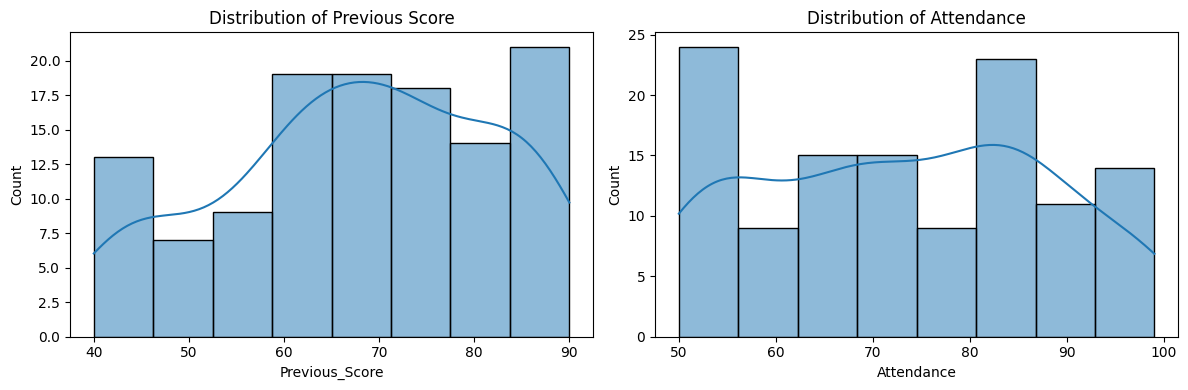

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Previous_Score"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Previous Score")

sns.histplot(df["Attendance"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Attendance")

plt.tight_layout()
plt.show()

In [73]:
#### Final Interpretation
print("Attendance has a stronger influence on passing than gender.")
print("If P(B|C) is much higher than P(B), then attendance significantly affects results.")
print("If P(B|A) is close to P(B), then gender has minimal influence.")
print("Normality-based probability calculations work better for variables that are close to symmetric and bell-shaped.")

Attendance has a stronger influence on passing than gender.
If P(B|C) is much higher than P(B), then attendance significantly affects results.
If P(B|A) is close to P(B), then gender has minimal influence.
Normality-based probability calculations work better for variables that are close to symmetric and bell-shaped.
